# 03 – 1D CNN Ablation Study for Automatic Modulation Classification

This notebook analyzes **pretrained** 1D CNN models for Automatic Modulation
Classification (AMC) using the RadioML 2016.10A dataset.

All models have already been trained using 8 different configurations (CONTROL + 7) as referenced from: https://arxiv.org/abs/1812.01187.  
**This notebook does NOT retrain any models.**  
Instead, it:

- Clones my GitHub repository into Colab (to access `/src` and `/models`).  
- Loads:
  - model weights (`.pth`)
  - training histories (`histories.pkl`)
  - ablation results (`ablation_results.csv` / `.pkl`)
  - summary plots (validation curves, loss curves, SNR curves)
- Rebuilds the 1D CNN architecture from `src/models_1d.py`.
- Evaluates accuracy, loss, and per-SNR performance on the RadioML 2016.10A test set.
---


## 0 Setup & Required Files





### 0.1 Dataset on Google Drive

- **Dataset**  
  - `RadioML2016_10A_dataset.pkl`  
  - Expected path in this notebook:  
    `/content/drive/MyDrive/AMC_datasets/RadioML2016_10A_dataset.pkl`

> If you store this file in a different place, update `data_path` in the first
> code cell accordingly.


In [ ]:
# Mount Google Drive (or configure to where dataset is located)
from google.colab import drive
drive.mount('/content/drive')

# Path to dataset (adjust this path to where the data file is located)
data_path = '/content/drive/MyDrive/AMC_datasets/RadioML2016_10A_dataset.pkl'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



### 0.2 GitHub Repository and Model Artifacts

GitHub repo: `Tutorial-Automatic-Modulation-Classification`

Cloned into:  `/content/Tutorial-Automatic-Modulation-Classification`

From that repo, this notebook uses:

- `src/models_1d.py` – 1D CNN architecture used for **all ablation configs**
- `src/data_utils.py` – helpers for building PyTorch dataloaders
- `src/eval_utils.py` – accuracy, confusion matrices, SNR curves
- `src/model_loading.py` – utilities to load ablation checkpoints
- `src/plot_utils.py` – consistent plotting helpers


In [ ]:
# --- Pull project from GitHub into Colab ---
import os, sys
REPO_URL = "https://github.com/Koosmaster/Tutorial-Automatic-Modulation-Classification.git"
REPO_DIR = "/content/Tutorial-Automatic-Modulation-Classification"
SRC_DIR  = f"{REPO_DIR}/src"

# Clone once
if not os.path.isdir(REPO_DIR):
    !git clone --depth 1 "$REPO_URL" "$REPO_DIR"

# Add src/ to import path
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("Loaded project from:", REPO_DIR)
print("src modules:", os.listdir(SRC_DIR))


Loaded project from: /content/Tutorial-Automatic-Modulation-Classification
src modules: ['__pycache__', 'models_1d.py', 'eval_utils.py', 'Sources.md', 'train.py', 'data.py', 'models', 'data_utils.py', 'plot_utils.py', 'exploration.py', 'model_loading.py']


Data & Model Access

The notebook loads:
- training histories from `data/histories.pkl`
- ablation summary tables from `data/ablation_results.pkl`
- pretrained CNN weights from `src/models/models1d_ablation_models.zip`

All evaluations (loss curves, accuracy tables, SNR curves) are computed
directly from these saved artifacts.


In [ ]:
import zipfile
import pandas as pd
DATA_DIR = os.path.join(REPO_DIR, "data")
zip_path = os.path.join(DATA_DIR, "ablation_results.zip")
IMG_DIR  = os.path.join(REPO_DIR, "images")

# Unzip
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(DATA_DIR)
    print("Extracted files:", zf.namelist())

csv_path = os.path.join(DATA_DIR, "ablation_results.csv")
pkl_path = os.path.join(DATA_DIR, "ablation_results.pkl")

if os.path.exists(csv_path):
    df_results = pd.read_csv(csv_path)
    print("Loaded:", csv_path)
elif os.path.exists(pkl_path):
    df_results = pd.read_pickle(pkl_path)
    print("Loaded:", pkl_path)
else:
    raise FileNotFoundError(
        "ZIP extracted, but no ablation_results.csv or ablation_results.pkl found."
    )

Extracted files: ['ablation_results.pkl', 'ablation_results.csv']
Loaded: /content/Tutorial-Automatic-Modulation-Classification/data/ablation_results.csv


In [ ]:
import sys
from models_1d import AMC1DCNN_v2
from data_utils import make_tensor_loader
from eval_utils import evaluate_model, snr_accuracy
from plot_utils import plot_confusion, plot_snr_curve, plot_history_curves


### 0.3 Imports and Configuration

Dependencies used in this notebook:

- **PyTorch**  
  For model definition, checkpoint loading, evaluation, and GPU acceleration.

- **NumPy**  
  For array operations, SNR-wise aggregation, and general numerical utilities.

- **Matplotlib / Seaborn**

  For producing training curves, SNR-dependent accuracy plots, and confusion matrices.

- **pandas**  
  For handling results tables, ablation summaries, and per-configuration metrics.

- **scikit-learn**  
  For metrics such as accuracy, classification report, and confusion matrices.


In [ ]:
# Main Libraries
import sys, platform
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
import random
import importlib
from IPython.display import Image, display

# Plotting Utilities
from IPython.display import HTML

# Train/Val/Test Splits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

If running in Google Colab, enable GPU acceleration for training deep models and mount Google Drive to access the dataset.

In [ ]:
# Environment check & dependency install
print(f"Python: {sys.version.split()[0]}  |  Platform: {platform.platform()}")

# Uncomment to install from requirements.txt if running locally
# %pip install -q -r requirements.txt

Python: 3.12.12  |  Platform: Linux-6.6.105+-x86_64-with-glibc2.35


---

## 1 Experiment Overview



### 1.1 Summary of Main Results (1D CNN)

Key quantitative findings from the 8-configuration training-pipeline ablation
on RadioML 2016.10A (35 epochs, batch size 256, raw I/Q):

- **Best 1D CNN configuration by validation accuracy**:  
  **A_ls_off** (label smoothing disabled)
  - Optimizer: SGD + Nesterov
  - Scheduler: StepLR (no warmup)
  - AMP: **on**
  - Mixup: **off**
  - Weight decay: applied only to conv / linear weights
    (batch-norm and bias excluded; `no_bias_decay = True`)
  - **Best validation accuracy**: **61.38%**  
  - **Test accuracy**: **61.70%**  
  - **Train time**: ≈ **177 s** (~2.9 min)

- **Baselines and other ablations (single runs)**  

| Config Name        | Val Best Acc (%) | Test Acc (%) | Train Time (s) |
|--------------------|------------------|--------------|----------------|
| CONTROL            | 61.19            | 61.61        | 187.85         |
| A_mixup_on         | 59.50            | 59.84        | 203.57         |
| A_ls_off           | 61.38            | 61.70        | 177.40         |
| A_sched_cosine     | 61.12            | 61.59        | 185.94         |
| A_warmup_on        | 61.14            | 61.67        | 184.98         |
| A_decay_all_params | 61.35            | 61.54        | 183.34         |
| A_opt_adam         | 60.66            | 61.12        | 188.78         |
| A_amp_off          | 61.34            | 61.73        | 159.23         |

- **Overall compute cost (single-seed sweep)**  
  - Per-run training time (across all configs): **~160–205 s**
    (~2.7–3.4 minutes).  
  - Full 8-config ablation sweep: **≈ 24.5 minutes** on a Colab GPU (A100).

**Takeaway.**

> - SGD + Nesterov, StepLR, AMP, and **no label smoothing**—gives the best
> validation accuracy and essentially ties for best test accuracy.
> - Turning label smoothing off (A_ls_off) yields a small but consistent gain
> over CONTROL, while mixup and Adam clearly underperform.
> - Differences between StepLR vs cosine LR, warmup vs no warmup, and different
> weight-decay groupings are minor compared to the effect of label
> smoothing and mixup.


---

## 2 Dataset Loading and Dataloaders




**Goal.** Prepare the RadioML I/Q data for deep learning models (PyTorch tensors), document the label choices, and explain how I split and reshape the data.

- **Labels.** Classification by **modulation type only**; SNR is stored separately and later used for per-SNR analysis.
- **Raw shapes.** Each sample is a complex baseband signal of shape `(2, 128)`, representing I and Q over 128 time points.
- **Splits.** Create train/validation/test splits stratified by modulation label with a fixed random seed for reproducibility.
- **Scaling / normalization.** I do not apply channel-wise normalization(keeping raw I/Q structure intact).
- **DL tensor format.**
  - For **1D CNNs**, inputs are shaped as `(batch_size, channels=2, length=128)`.


Dataset Summary
- **Source:** RadioML 2016.10A (DeepSig)  
- **Format:** Pickle file (`.pkl`) containing I/Q signal samples  
- **Classes:** 11 modulation types (8 digital, 3 analog)  
- **SNR Range:** –20 dB to +18 dB (2 dB steps)  
- **Samples:** Each record has 128 complex I/Q samples  

---
SOURCE: https://www.kaggle.com/code/ahmedali30/knndtamc-amc-rml2016a-updated


### 2.1 Load Preprocessed RadioML Dataset

I load:
- `X_val`, `y_val`  
- `X_test`, `y_test`  
- `snr_test` values (for SNR-dependent accuracy)

The input shape for all models is:

In [ ]:
# Importing functions from Github in the src file
from data import load_radioml_pkl_dataset, radioml_splits
from data_utils import dict_to_iq_arrays

In [ ]:
radioml_data, mod_classes, snr_values = load_radioml_pkl_dataset(data_path)
X, y, snr_list = dict_to_iq_arrays(radioml_data)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("snr_list shape:", snr_list.shape)


Loading RadioML 2016.10A dataset from: /content/drive/MyDrive/AMC_datasets/RadioML2016_10A_dataset.pkl
Found 11 raw modulation types.
Loaded dataset contains 11 modulation classes and 20 SNR values.
Dataset summary: 11 mods, 20 SNRs, 220,000 total samples.
X shape: (220000, 2, 128)
y shape: (220000,)
snr_list shape: (220000,)


### 2.2 Dataloader Construction

PyTorch `DataLoader` for:
- validation set  
- test set  
- SNR-labeled test set  

Batch size = **256**  

In [ ]:
# Encode modulation labels to integers 0..C-1
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Train / val / test splits (e.g., 70 / 15 / 15)
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X, y_enc, snr_list, test_size=0.3, stratify=y_enc, random_state=42
)

X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Convert labels to tensors
y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()




---

## 3 1D CNN Architecture



### 3.1 Model Definition

This ablation uses a single **shared backbone**; only the *training strategy* changes across configs.


**Design notes**
- Small kernels + BN + ReLU = stable training and fewer params (based on the Bag-of-Tricks paper).
- Max pooling halves temporal length per stage (128→16) while growing channels.
- GAP summarizes each feature map; the classifier operates on a compact 128-d vector.
- All 8 ablation runs keep this backbone fixed; then I vary optimizer/scheduler/regularizers.

**Params & Compute**

- Total trainable params: **132,171**  
- Mult-adds (≈ FLOPs/2): **~3.99M** per sample  
- Est. model memory: **~0.93 MB**
---


### **Model Architecture**

| Component     | Setting                                                                                  |
|--------------|-------------------------------------------------------------------------------------------|
| Input shape   | (2 channels, 128 samples)                                                                |
| Conv blocks   | 3 stages, each: (Conv1d(k=3, s=1, p=1) → BatchNorm1d → ReLU) × 2                         |
| Channels      | 2 → 32 → 64 → 128  (input → stage 1 → stage 2 → stage 3)                                |
| Pooling       | MaxPool1d(kernel_size=2, stride=2) after each stage                                     |
| Global pooling| AdaptiveAvgPool1d(1) → 128-d feature vector                                             |
| Classifier    | Linear 128 → 256 (ReLU, Dropout 0.5) → Linear 256 → 11 classes                          |
| Weight init   | Kaiming normal for Conv1d + Linear; BatchNorm1d with γ = 1, β = 0                       |
| Params        | ≈ 132k trainable parameters (132,171)                                                   |


---

### **Optimization**
| Parameter              | Setting                                                                                  |
|------------------------|------------------------------------------------------------------------------------------|
| Optimizer              | SGD + Nesterov momentum                                                                  |
| Momentum               | 0.9                                                                                      |
| Initial Learning Rate  | 0.10                                                                                     |
| Weight Decay           | 1e-4 on **Conv/Linear weight tensors only**; BatchNorm and bias have **no** weight decay |
| AMP                    | Enabled (mixed precision)                                                                |


---

### **Scheduler**
| Parameter | Setting                                                                                      |
|----------|----------------------------------------------------------------------------------------------|
| Type     | StepLR                                                                                       |
| Step Size| ⌊epochs / 3⌋ = **11** for 35-epoch ablation runs                                             |
| Gamma    | 0.10                                                                                         |
| Warmup   | Disabled for the best config (a warmup ablation did not improve performance)                |


---

### **Regularization**
| Parameter       | Setting                                                                                          |
|----------------|--------------------------------------------------------------------------------------------------|
| Label Smoothing| **0.0** (best config A_ls_off); CONTROL used 0.1 and performed slightly worse                     |
| Mixup          | Disabled (a mixup-on ablation reduced validation and test accuracy on raw I/Q)                   |
| Dropout        | 0.5 in the classifier MLP only                                                                   |
| BatchNorm      | Applied after every Conv1d layer                                                                 |


---

### **Training Configuration**
| Parameter  | Setting                                                                                 |
|-----------|------------------------------------------------------------------------------------------|
| Precision | AMP (mixed precision)                                                                    |
| Batch Size| 256                                                                                      |
| Epochs    | Ablation runs trained for **35 epochs** with best-epoch checkpointing by val accuracy    |
| Shuffle   | True (per-epoch shuffling in the training DataLoader)                                   |

---
### **Performance (Ablation Study Results)**
| Metric                            | Value                                           |
|-----------------------------------|-------------------------------------------------|
| Test Accuracy (single seed)       | **0.6170** (61.70%)                             |
| Best Configuration                | **A_ls_off** (label smoothing disabled)        |
| Train Time per Run (A_ls_off)     | **177 s** ≈ 2.9 minutes on a Colab GPU         |
| Low-SNR Accuracy (≤ 0 dB)         | To be filled from SNR-curve analysis section   |

---

### **Summary**

- **Label smoothing:** Disabling label smoothing (`A_ls_off`, LS = 0.0) gave the **best validation and test accuracy**, slightly outperforming the CONTROL setup with LS = 0.1, so the final configuration uses **no label smoothing**.
- **Weight decay:** Keeping weight decay on **Conv/Linear weights only** (no decay on BatchNorm or bias) worked best. Applying weight decay to **all** parameters did **not** improve performance.
- **AMP vs FP32:** Enabling AMP gave **similar accuracy** to full FP32; the non-AMP run was slightly faster and essentially tied on test accuracy. AMP is kept as the default mainly for numerical and practical convenience, not because of a large accuracy gain.
- **Mixup:** Turning on mixup **hurt performance** on raw I/Q (both validation and test accuracy dropped), suggesting that heavy linear mixing of examples distorts modulation structure in this setting.
- **Warmup:** Adding a learning-rate warmup phase did **not** provide a clear benefit over the simpler no-warmup schedule for this architecture and dataset.
- **Adam vs SGD:** Switching from SGD + Nesterov to Adam produced **slightly worse** validation and test accuracy with no clear upside, so SGD remains the preferred optimizer.
- **Scheduler choice:** StepLR and cosine schedules were **broadly comparable**; StepLR showed a slight edge and is retained for simplicity, with best-epoch checkpointing used instead of training to a fixed final epoch.



### Relation to Prior Work and Why the Input Reshaping Looks the Way It Does

The way I reshape the I/Q data for each deep-learning model isn’t arbitrary. It follows the exact conventions used in the core papers that introduced deep learning for RF waveforms and modulation classification. These three references all use the same I/Q structure and point toward the same tensor formats I adopt in this notebook.

---

#### **(1) O’Shea & Hoydis (2017) – An Introduction to Deep Learning for the Physical Layer**  
https://arxiv.org/abs/1702.00832

O’Shea and Hoydis frame baseband I/Q as a **two-channel time-series**. For CNNs, they treat I and Q as separate channels over N time samples:

- channels = 2  
- length = N  
- shape = `(2, N)`

This directly supports the **1D CNN format** I use here:


## 4 Training Utilities



### 4.1 Loss Functions, Metrics, LR Schedules

- **Loss function**
  - CrossEntropyLoss with **configurable label smoothing**:
    - Baseline (CONTROL): ε = 0.1
    - Best config (A_ls_off): ε = 0.0 (label smoothing disabled)

- **Metrics**
  - Top-1 accuracy for validation and test.
  - **Per-SNR accuracy** on the test set (accuracy vs. SNR curve).
  - Aggregated **AUC over SNR** and **Expected Calibration Error (ECE)** reported for selected runs.

- **Optimizers**
  - **SGD + Nesterov momentum (0.9)** with weight decay (default).
  - **Adam** (β₁ = 0.9, β₂ = 0.999) in a dedicated Adam ablation.

- **Learning-rate schedules**
  - **StepLR** (default): step size = ⌊epochs / 3⌋ (≈ 11 for 35-epoch runs), γ = 0.1.
  - **Cosine annealing** as an alternative schedule in a separate ablation.

- **Warmup**
  - Optional **linear warmup** (LinearLR) for the first few epochs (≈ 3–5),
    applied on top of the main scheduler in a warmup ablation; not used in the best config.

- **Weight-decay policies**
  - **Default / best**: apply weight decay only to **Conv/Linear weights**; **exclude BatchNorm and bias** parameters.
  - Alternative ablation: apply weight decay to **all parameters**, which did not improve performance.

- **Precision modes**
  - **AMP (mixed precision)** enabled in most configurations (including CONTROL).
  - **FP32** (AMP disabled) tested in a dedicated ablation; accuracy was similar, with modest differences in speed.




---

## 5 Ablation Configurations

### 5.1 Overview of the 8 Configurations

Evaluation of **eight** training-pipeline configurations, all using the same 1D CNN backbone:

- **CONTROL** configuration (baseline recipe).
- **Mixup augmentation**: mixup disabled (CONTROL) vs enabled (A_mixup_on).
- **Label smoothing**: ε = 0.1 (CONTROL) vs ε = 0.0 (A_ls_off).
- **Optimizer choice**: SGD + Nesterov (CONTROL) vs Adam (A_opt_adam).
- **Learning-rate schedule**: StepLR (CONTROL) vs cosine annealing (A_sched_cosine).
- **Warmup strategy**: no warmup (CONTROL) vs linear warmup on top of the main scheduler (A_warmup_on).
- **Weight-decay policy**: decay on Conv/Linear weights only (CONTROL) vs decay on all parameters, including BatchNorm and bias (A_decay_all_params).
- **Precision mode**: AMP mixed precision (CONTROL) vs full FP32 (A_amp_off).

Each ablation toggles **one knob at a time** relative to CONTROL, isolating the contribution of that specific configuration to final performance.





### 5.2 Full Configuration Comparison Table

1D CNN Ablation Configurations – Parameter Comparison

| Config Name        | Mixup | Label Smoothing | Optimizer | Scheduler | Warmup | Bias/BN Decay Disabled? | AMP? |
|--------------------|:-----:|:---------------:|:---------:|:---------:|:------:|:------------------------:|:----:|
| **CONTROL**        |   ✘   |      0.1        |   SGD     |  StepLR   |   ✘    |           ✔              |  ✔   |
| **A_mixup_on**     |   ✔   |      0.1        |   SGD     |  StepLR   |   ✘    |           ✔              |  ✔   |
| **A_ls_off**       |   ✘   |      0.0        |   SGD     |  StepLR   |   ✘    |           ✔              |  ✔   |
| **A_sched_cosine** |   ✘   |      0.1        |   SGD     |  Cosine   |   ✘    |           ✔              |  ✔   |
| **A_warmup_on**    |   ✘   |      0.1        |   SGD     |  StepLR   |   ✔    |           ✔              |  ✔   |
| **A_decay_all_params** | ✘ |      0.1        |   SGD     |  StepLR   |   ✘    |           ✘              |  ✔   |
| **A_opt_adam**     |   ✘   |      0.1        |   Adam    |  StepLR   |   ✘    |           ✔              |  ✔   |
| **A_amp_off**      |   ✘   |      0.1        |   SGD     |  StepLR   |   ✘    |           ✔              |  ✘   |

**Legend:** ✔ = enabled, ✘ = disabled


---

## 6 Loading Pretrained Results



### 6.1 Load Training Histories

Loads `histories.pkl`, containing per-epoch:
- train loss  
- validation loss  
- train accuracy  
- validation accuracy  

for **all 8 configurations** (CONTROL + 7 ablations).


In [ ]:
pkl_path = os.path.join(DATA_DIR, "histories.pkl")
with open(pkl_path, "rb") as f:
    histories = pickle.load(f)



### 6.2 Load Ablation Summary Table

Load the precomputed ablation results stored in `ablation_results.csv`

For each of the 8 configurations the table contains:
- best validation accuracy
- overall test accuracy
- total training time (seconds)

In [ ]:
print(df_results)

           Experiment  Val Best Acc (%)  Test Acc (%)  Train Time (s)
0             CONTROL         61.193939     61.609091      187.852502
1          A_mixup_on         59.503030     59.842424      203.571948
2            A_ls_off         61.381818     61.703030      177.397206
3      A_sched_cosine         61.121212     61.587879      185.937268
4         A_warmup_on         61.142424     61.672727      184.980837
5  A_decay_all_params         61.345455     61.536364      183.344798
6          A_opt_adam         60.660606     61.121212      188.775827
7           A_amp_off         61.342424     61.733333      159.225532


### 6.3 Load Best Model Weights

This section loads the best pretrained 1D CNN produced by the **code only** ablation notebook.

In [ ]:
import model_loading
importlib.reload(model_loading)
from model_loading import load_ablation_model
model_A_ls_off = load_ablation_model("1dcnn_A_ls_off", AMC1DCNN_v2)


## 7 Validation Accuracy vs Epoch

### 7.1 Multi-Curve Validation Accuracy Plot

Validation accuracy curves for all 8 configurations.

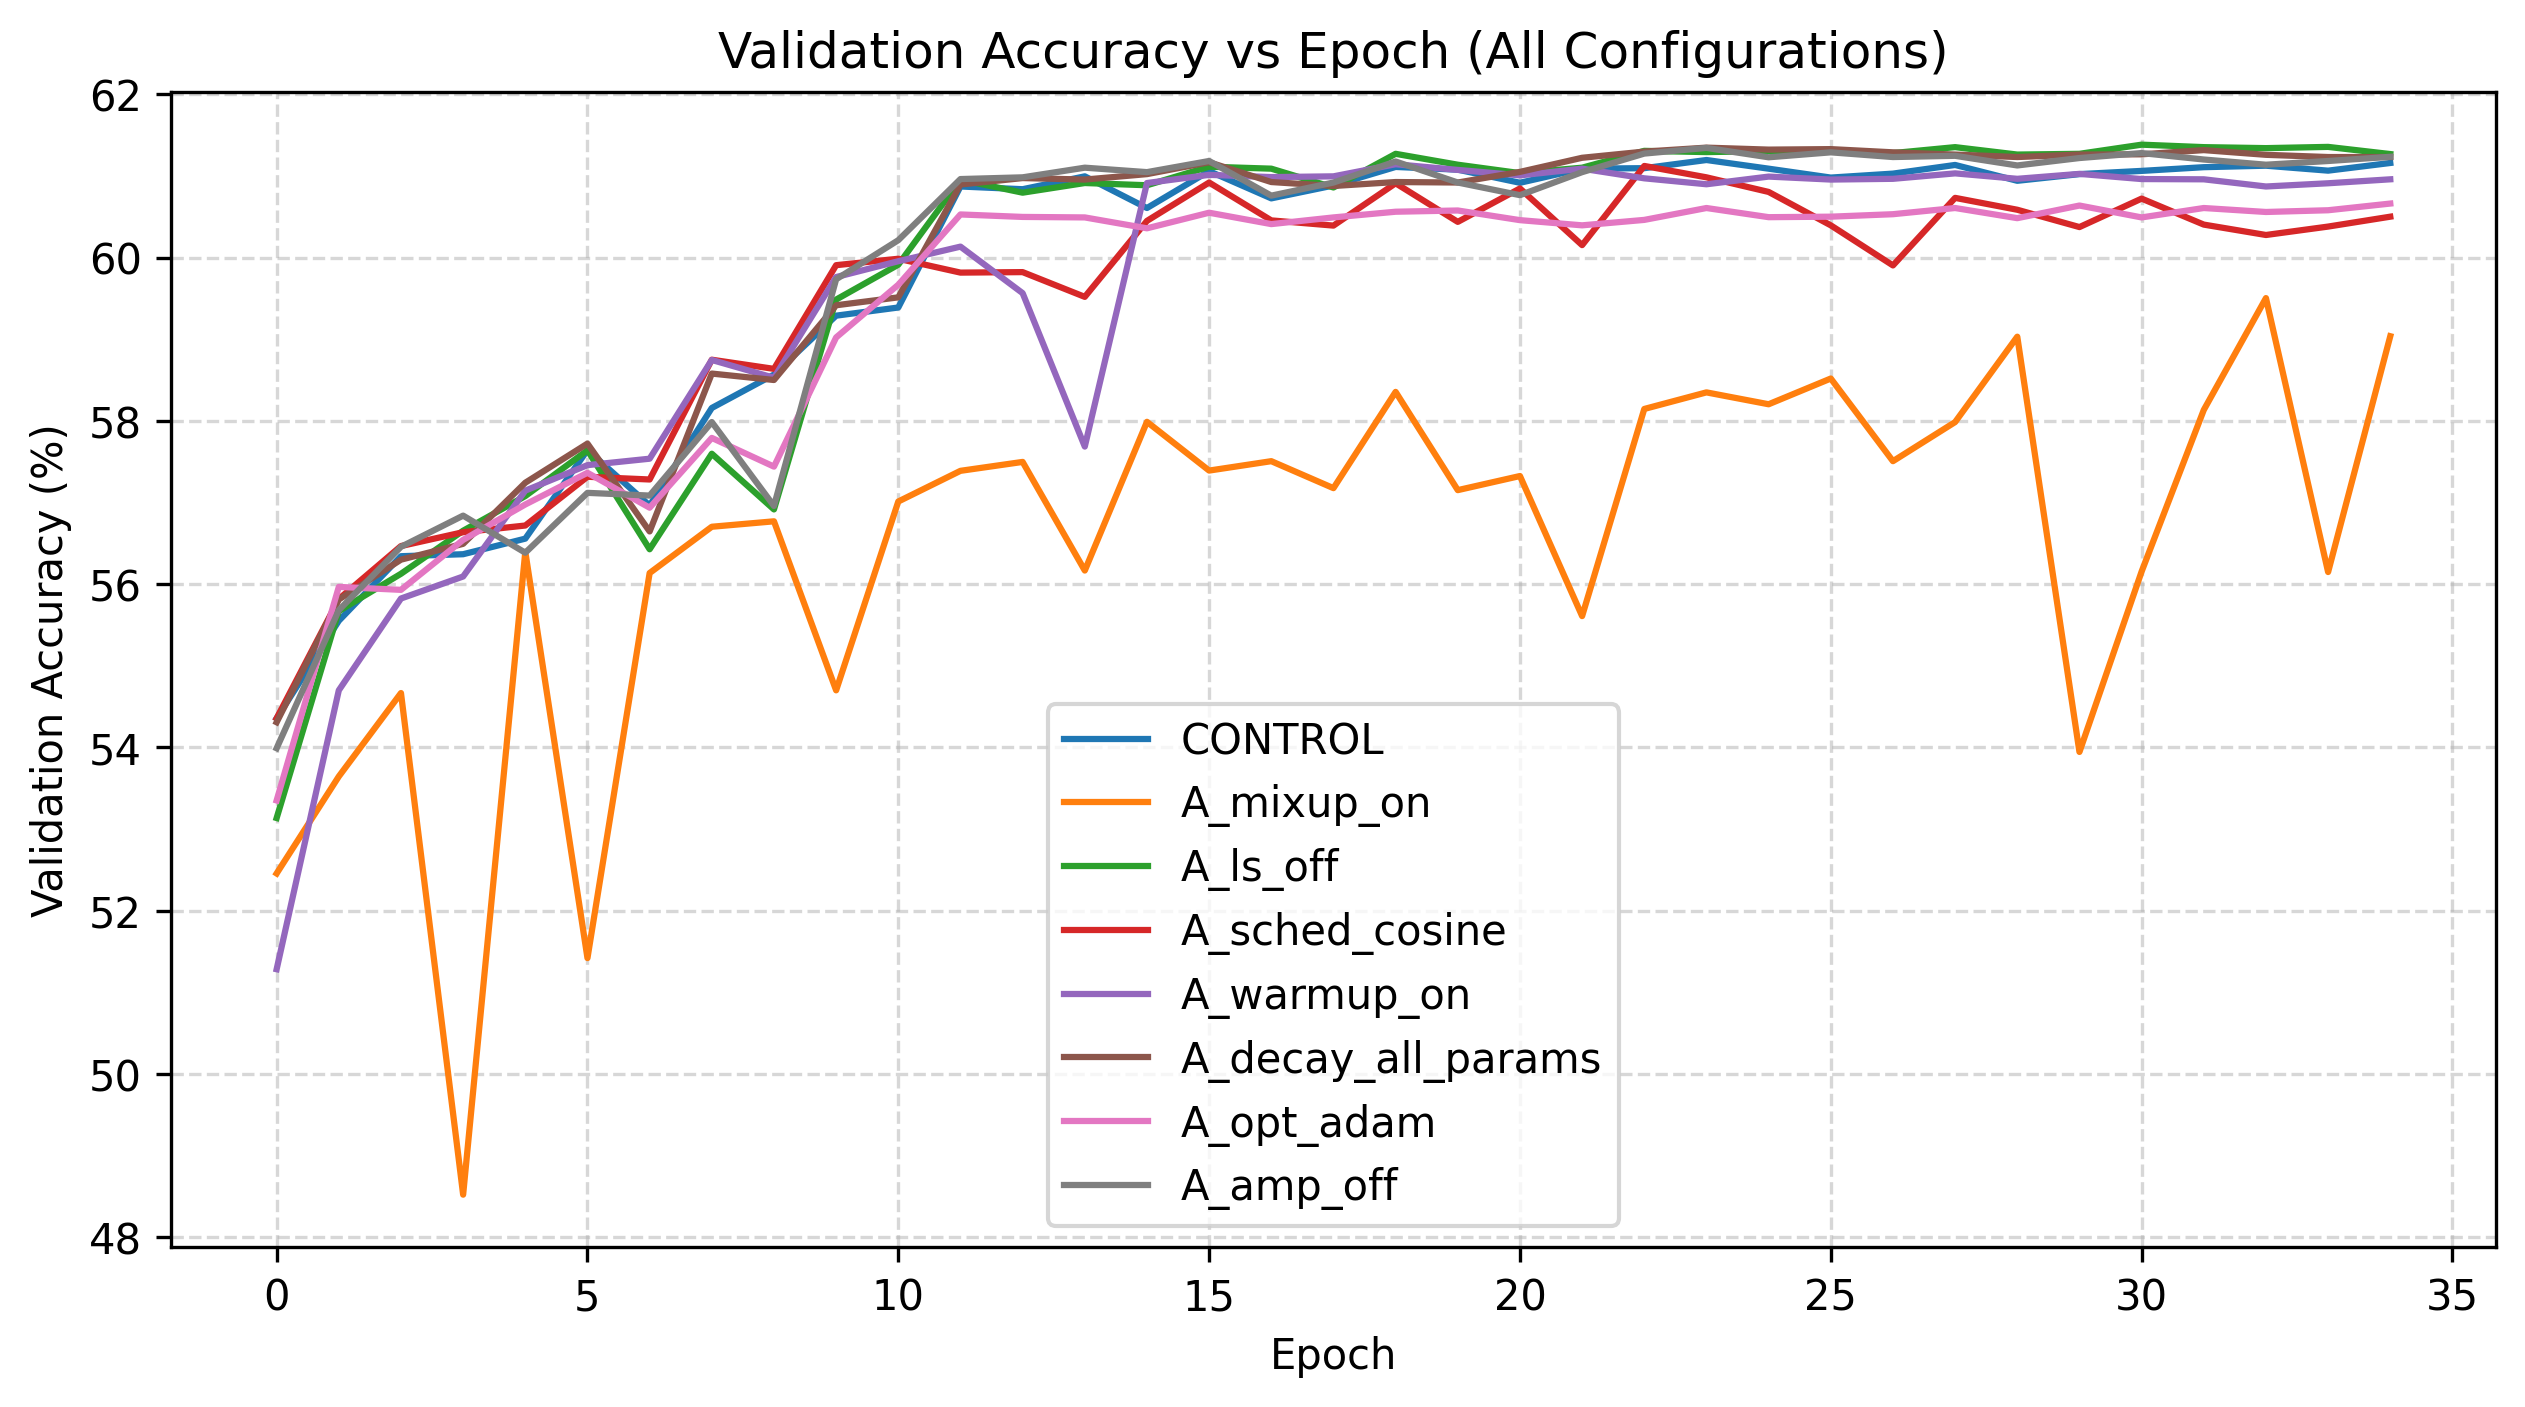

In [ ]:
ZIP_PATH = os.path.join(IMG_DIR, "plots.zip")
display(Image(os.path.join(IMG_DIR, "val_accuracy_all_configs.png")))


### 7.2 Interpretation

Key observations:

- All non-mixup configurations (CONTROL, A_ls_off, A_sched_cosine, A_warmup_on,
  A_decay_all_params, A_opt_adam, A_amp_off) climb rapidly in the first
  ~10–15 epochs and then plateau in the **≈61–62%** validation-accuracy range
  by epochs 20–35; later epochs give only marginal gains.
- **A_mixup_on** is clearly the outlier: its curve is noisier and remains
  several percentage points below the others for the entire training run,
  confirming that mixup on raw I/Q is harmful here.
- **A_ls_off** (no label smoothing) and **A_amp_off** (FP32) stay near the
  top of the pack for most of training and finish with some of the highest
  validation accuracies.
- The scheduler, warmup, and weight-decay variants (**A_sched_cosine**,
  **A_warmup_on**, **A_decay_all_params**) largely track CONTROL, with only
  minor differences in peak accuracy and curve shape.
- The **Adam** variant (**A_opt_adam**) roughly follows the SGD curves but
  does **not** deliver a clear advantage in convergence speed or final
  validation accuracy.
- The overlap between **AMP (CONTROL)** and **FP32 (A_amp_off)** curves shows
  that mixed precision is at least as accurate as FP32 in this setting; the
  choice between them is driven more by speed and practicality than by
  validation performance.


---

## 8 Loss Curves (Train & Val)

The loss curves for all eight configurations summarize optimization stability, overfitting, and how each training configuration affects convergence.


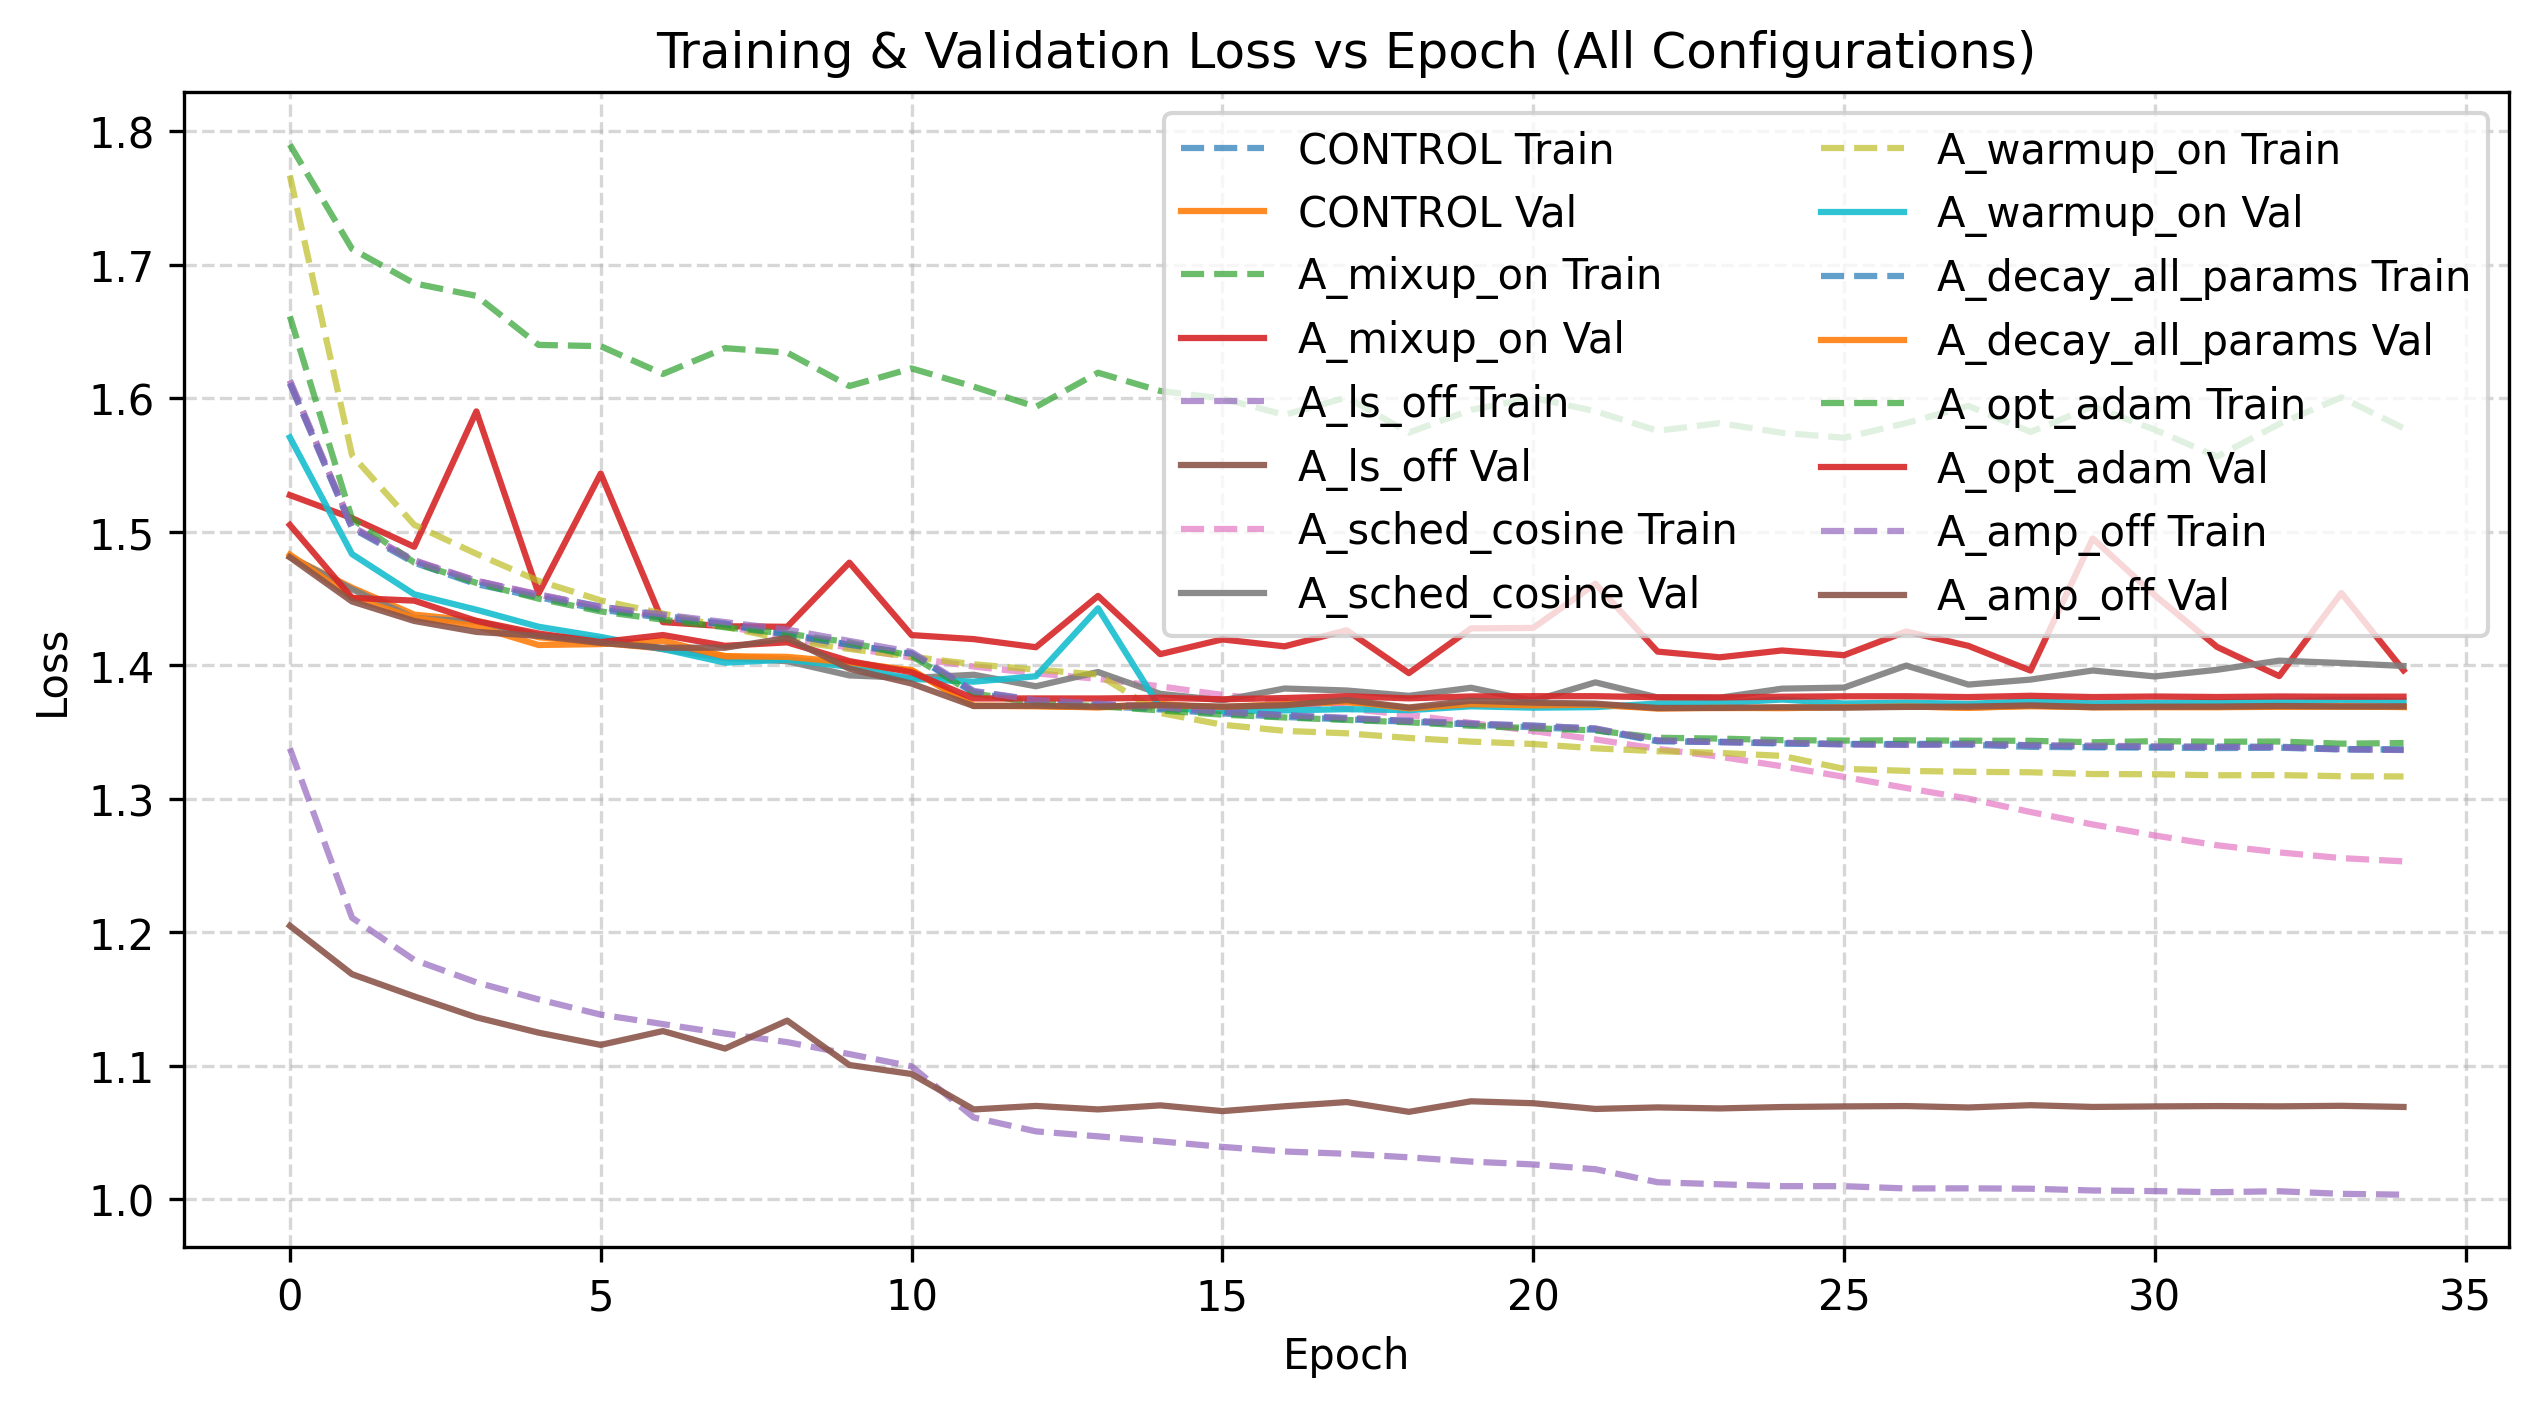

In [ ]:
display(Image(os.path.join(IMG_DIR, "loss_curves_all_configs.png")))

### Interpretation

From the plotted loss curves:

- **Overall behaviour (non-mixup configs)**  
  CONTROL, A_ls_off, A_sched_cosine, A_warmup_on, A_decay_all_params,
  A_opt_adam, and A_amp_off all show smooth decreases in training
  loss from ≈1.5 to ≈1.0–1.4, with validation loss following closely and
  flattening around ≈1.35–1.40. There is a slight train–val gap, but no
  severe overfitting within 35 epochs.

- **A_mixup_on (mixup enabled)**  
  Clearly the worst behaved: both training and validation loss remain
  noticeably higher than the other configurations and the validation curve is
  more jittery. This reinforces that mixup on raw I/Q harms optimization.

- **A_amp_off (FP32)**  
  Achieves the **lowest training and validation loss** of all runs, with very
  smooth curves. It fits the data more aggressively, but the validation loss
  also improves, matching its slightly better single-run accuracy.

- **A_ls_off (no label smoothing)**  
  Tracks CONTROL closely and ends with slightly lower validation loss, showing
  that turning off label smoothing does **not** destabilize training and can
  even help.

- **Scheduler / warmup / weight-decay / Adam variants**  
  A_sched_cosine, A_warmup_on, A_decay_all_params, and A_opt_adam remain close
  to CONTROL throughout training. Their loss curves differ only subtly,
  indicating that these knobs have relatively minor impact on overall
  optimization compared to mixup and label smoothing.



---

## 9 Quantitative Results Table


### 9.1 Final Accuracy Metrics

The table below reports the final performance metrics for all **8** ablation
configurations (CONTROL + 7 one-knob variants), including:

- **Best validation accuracy**
- **Overall test accuracy**
- **Training time** (seconds and minutes)

These metrics summarize how each training configuration impacts final model quality and
computational cost.


Table: Final Metrics for All 1D CNN Ablation Configurations

| Config Name             | Val Best Acc (%) | Test Acc (%) | Train Time (s) | Train Time (min) |
|-------------------------|------------------|--------------|----------------|------------------|
| **CONTROL**             | 61.19            | 61.61        | 187.85         | 3.13             |
| **A_mixup_on**          | 59.50            | 59.84        | 203.57         | 3.39             |
| **A_ls_off**            | **61.38**        | 61.70        | 177.40         | 2.96             |
| **A_sched_cosine**      | 61.12            | 61.59        | 185.94         | 3.10             |
| **A_warmup_on**         | 61.14            | 61.67        | 184.98         | 3.08             |
| **A_decay_all_params**  | 61.35            | 61.54        | 183.34         | 3.06             |
| **A_opt_adam**          | 60.66            | 61.12        | 188.78         | 3.15             |
| **A_amp_off**           | 61.34            | **61.73**    | 159.23         | 2.65             |


### 9.2 Interpretation

- **A_ls_off** (no label smoothing) achieves the **highest validation accuracy**
  and essentially ties for best test accuracy, so it is selected as the final
  configuration. Removing label smoothing slightly improves both validation and
  test performance without hurting stability.

- **A_amp_off** (FP32) attains the **highest single-run test accuracy**
  (61.73%) and the lowest loss, but its validation accuracy is marginally lower
  than A_ls_off and the differences are well within run-to-run noise.

- **A_mixup_on** severely degrades performance: both validation and test
  accuracy drop by ~2 percentage points compared to CONTROL, confirming that
  mixup on raw I/Q is harmful for this CNN.

- **Scheduler, warmup, and weight-decay variants**  
  (**A_sched_cosine**, **A_warmup_on**, **A_decay_all_params**) track the
  CONTROL configuration very closely in both accuracy and training time; none
  offers a clear systematic advantage. Applying weight decay to *all*
  parameters (A_decay_all_params) does **not** outperform the selective
  weight-decay policy.

- **A_opt_adam** (Adam optimizer) performs slightly worse than the SGD
  configurations in both validation and test accuracy, offering no compelling
  benefit in this setting.

Overall, the ablation suggests that the most impactful choices are **turning
off label smoothing** and **avoiding mixup**; other “tricks” (Adam, cosine LR,
warmup, decay-all-params, AMP vs FP32) yield only small, largely cosmetic
differences.


## 10 Accuracy vs SNR Curves

The plot below shows SNR-dependent **test accuracy** for all 8 configurations
from −20 dB to +18 dB.

### Interpretation

- At **very low SNR (≤ −10 dB)** all configurations are nearly identical and
  close to chance; the choice of optimizer/scheduler/precision has little
  visible effect in this regime.

- Between **−8 dB and 0 dB**, the curves begin to separate slightly.  
  The non-mixup configs (CONTROL, A_ls_off, A_sched_cosine, A_warmup_on,
  A_decay_all_params, A_opt_adam, A_amp_off) cluster tightly together, while  
  **A_mixup_on** is consistently a bit lower (≈1–2 percentage points).

- For **mid to high SNR (0–10 dB)**, the non-mixup configurations are almost
  indistinguishable; small differences (e.g., A_ls_off, A_amp_off, or
  A_sched_cosine occasionally on top) are within expected noise. Mixup remains
  the only configuration that is clearly below the pack.

- At **very high SNR (≥ 10 dB)** all models converge to similar accuracy
  (≈88–90%), indicating that once the signal is clean, these training-trick
  choices have minimal impact on performance.

- Adam vs SGD, StepLR vs cosine, warmup on/off, selective vs all-parameter
  weight decay, and AMP vs FP32 all yield **very similar SNR curves**; their
  effect on robustness is small compared to the effect of enabling mixup.

### Summary

- **A_mixup_on** is consistently worse across almost the entire SNR range,
  confirming that mixup on raw I/Q hurts robustness.
- All other configurations behave very similarly as a function of SNR; the
  choice of final model (A_ls_off) is driven more by small overall
  validation/test improvements than by large SNR-specific differences.


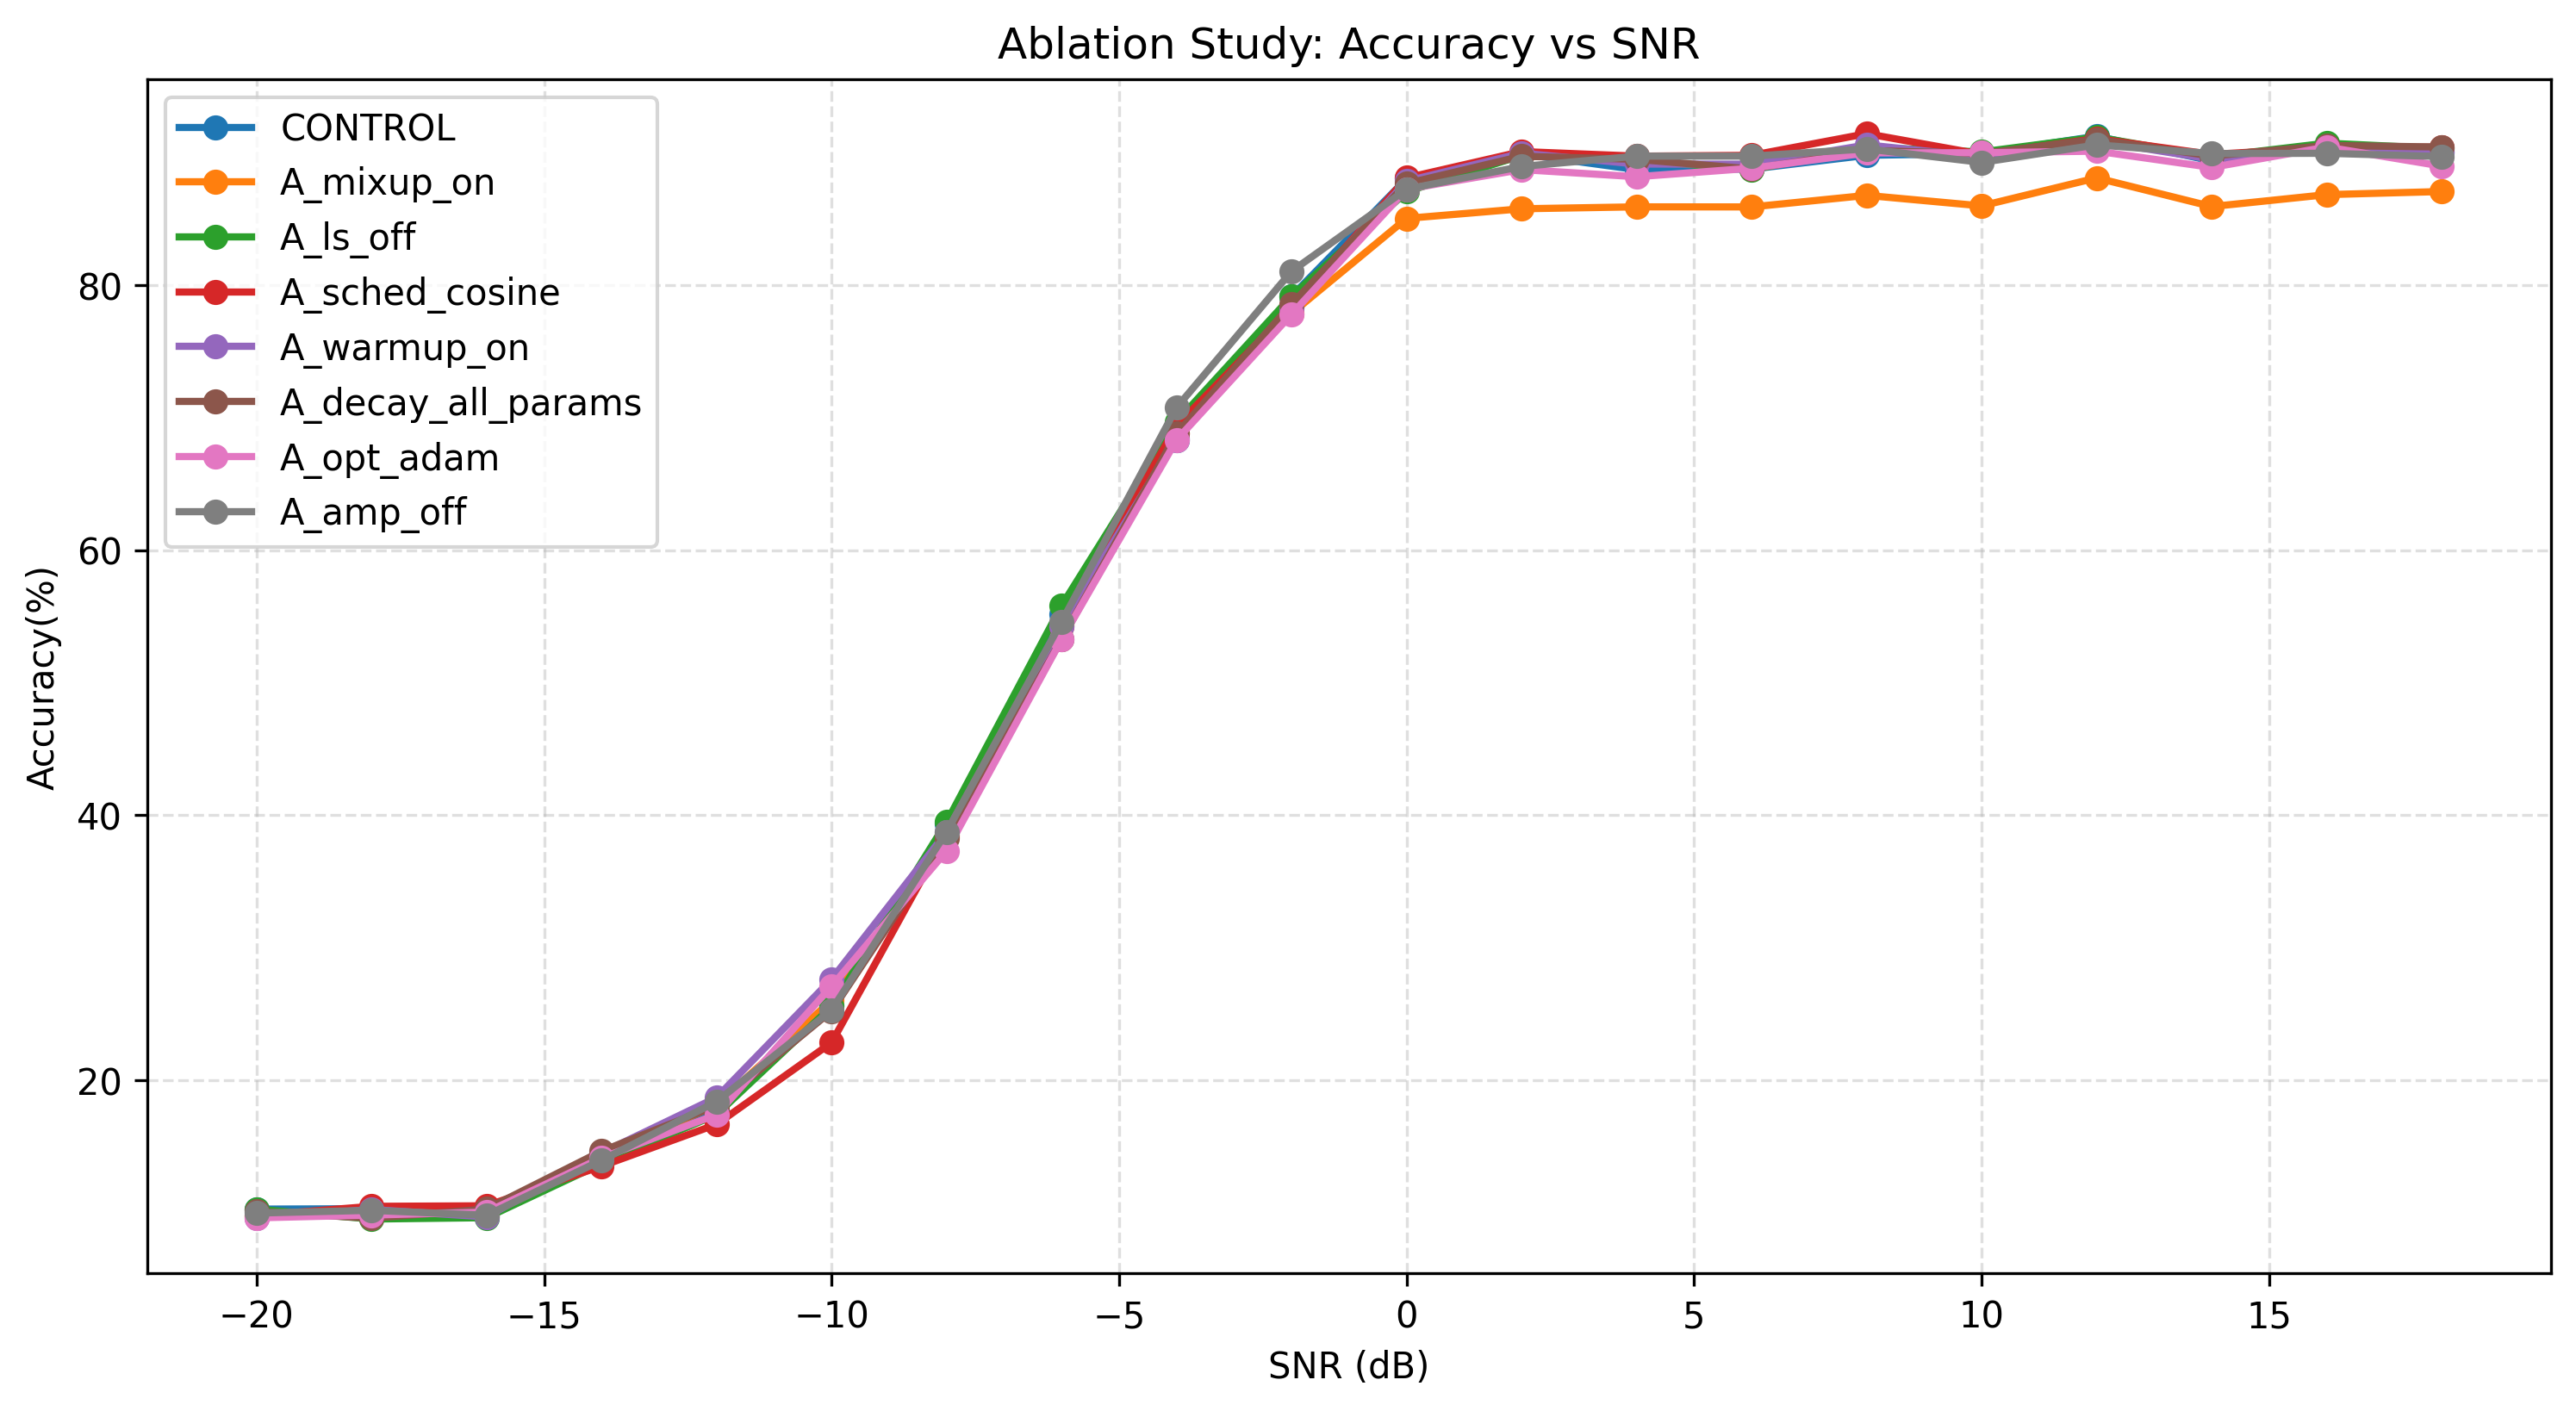

In [ ]:
display(Image(os.path.join(IMG_DIR, "snr_accuracy_comparison.png")))



---


## 11 Final Selected Model

Based on the full ablation study—validation and test accuracy, SNR-dependent
performance, optimization stability, and training efficiency—the final 1D CNN
configuration selected for Automatic Modulation Classification is:

> **A_ls_off** – SGD + Nesterov, StepLR, AMP, no mixup, **label smoothing disabled (ε = 0.0)**, and weight
> decay applied only to Conv/Linear weights (no decay on BN/bias).

A_ls_off was chosen because it:

- Achieves the **highest validation accuracy** among all 8 configs
  (best val acc ≈ **61.38%**), and essentially ties for best **single-run test accuracy**
  (≈ **61.70%**).
- Shows **smooth, stable training and validation curves**, comparable to or
  better than other SGD-based variants.
- Matches the best configurations in **SNR-dependent accuracy** across the
  whole −20 to +18 dB range, with no degradation at low SNR.
- Is **simple and efficient**: no mixup, no warmup, standard StepLR, and
  selective weight decay.
- When retrained on **Train ∪ Val** for multiple seeds (42, 43, 44), yields a
  **mean test accuracy ≈ 61.75%**, confirming that its performance is robust
  to randomness.

Other configurations such as **A_amp_off** (FP32) reach very similar test
accuracy, but A_ls_off is retained as the final model because it is the
validation-selected winner and performs consistently well across all analyses.






#### 11.1 Final Model Configuration (A_ls_off)

- **Optimizer:** SGD + Nesterov momentum (0.9)
- **Weight decay:** applied to **Conv/Linear weights only**  
  (BatchNorm and bias parameters are excluded from weight decay.)
- **Learning-rate scheduler:** StepLR  
  - γ = 0.1  
  - Step size = ⌊epochs / 3⌋ (≈ 11 for 35-epoch ablation runs)
- **Label smoothing:** ε = **0.0** (disabled)  
  (Ablation showed turning off label smoothing gives the best validation and
  test accuracy.)
- **Mixup:** Disabled  
  (Ablation showed mixup adds noise and consistently **reduces** accuracy for
  this 1D raw I/Q CNN.)
- **Precision:** AMP (mixed precision) **enabled**  
  (Provides accuracy comparable to FP32 with better throughput.)
- **Warmup:** Disabled  
  (A warmup ablation did not provide a consistent benefit with StepLR.)
- **Batch size:** 256
- **Epoch selection:** Best checkpoints typically occur in the **late-epoch
  range (~25–35)**; final Train∪Val runs train for the best epoch found in the
  ablation (by validation accuracy).

Model Architecture:
- **Backbone:** 1D CNN with Conv1d → BatchNorm1d → ReLU blocks and MaxPool1d
- **Channels:** 2 input channels (I and Q), feature stages 2 → 32 → 64 → 128
- **Output:** 11-class modulation classifier (11 modulation types)

### 11.2 Final Performance


**Final Model vs. Baseline Performance**

| Metric                                | Baseline (CONTROL)            | Final Model (A_ls_off)          | Difference / Comment                          |
|---------------------------------------|-------------------------------|---------------------------------|-----------------------------------------------|
| **Best Val Accuracy**                 | 61.19%                        | **61.38%**                      | **+0.19 pts** (small but consistent gain)     |
| **Test Accuracy (single-seed)**       | 61.61%                        | **61.70%**                      | **+0.09 pts**                                 |
| **Mean Test Acc (Train∪Val, 3 seeds)**| —                             | **≈61.75%**                     | Final multi-seed result for A_ls_off          |
| **Train Time per Run**                | 187.9 s (≈3.13 min)           | **177.4 s (≈2.96 min)**         | **≈10.5 s faster** (~6% faster)              |
| **Low-/High-SNR Accuracy**            | Very similar to A_ls_off      | Very similar to CONTROL         | Differences are within plotting noise         |
| **Stability (loss/accuracy curves)**  | Smooth, mild overfitting      | **Similarly smooth / stable**   | No degradation; behaviour matches baseline    |
| **Label Smoothing**                   | ε = 0.1                       | **ε = 0.0 (disabled)**          | Simpler recipe, slightly better accuracy      |
| **Optimizer**                         | SGD + Nesterov                | SGD + Nesterov                  | Identical                                     |
| **Inference Precision**               | AMP (mixed precision)         | AMP (mixed precision)           | Identical                                     |

**Key Takeaway**

Compared to the CONTROL baseline, the final model **A_ls_off** delivers a
*modest but consistent* improvement in validation and test accuracy and is
slightly faster to train, while maintaining equally smooth and stable
optimization. The main lessons from the ablation are that **disabling label
smoothing** and **avoiding mixup** are beneficial, whereas other tricks
(Adam, cosine LR, warmup, all-parameter weight decay, AMP vs FP32) have only
minor effects on overall performance.


---

## 12 Discussion & Takeaways

The ablation highlights a few patterns in how this 1D CNN learns raw I/Q.

### Lessons learned from the ablation

- **Training configurations mostly affect stability and speed, not headline accuracy.**  
  Across all 8 configurations (excluding mixup), validation and test accuracy
  cluster tightly around **61–62%**. Changes to optimizer, scheduler, warmup,
  weight-decay policy, AMP vs FP32, etc., shift curves slightly but do not
  fundamentally change the performance ceiling.

- **The 1D CNN appears to plateau around ~61–62% on this setup.**  
  Once the backbone and data split are fixed, almost all “reasonable” training
  configurations converge to the same accuracy band. This suggests that *architecture*
  and representation, rather than more configurations, are the main bottlenecks.

- **Mixup clearly hinders raw I/Q waveform learning.**  
  The mixup-on configuration (A_mixup_on) underperforms
  and has worse loss curves, indicating that linear mixing of examples distorts
  modulation structure in a way this 1D CNN cannot easily undo.

- **Disabling label smoothing helps slightly.**  
  The best config (A_ls_off) sets ε = 0.0 and achieves the highest validation
  accuracy. Therefore, label smoothing is
  not helpful for this particular architecture/dataset combination.

- **Scheduler, warmup, and weight decay have minor effects.**  
  StepLR vs cosine, warmup vs no warmup, and “all-parameter” vs selective
  weight decay all produce very similar accuracies and loss curves. Selective
  decay (no decay on BN/bias) is marginally preferred, but these knobs don't matter compared to mixup / label smoothing.

- **AMP vs FP32 are not that different.**  
  The AMP-on and AMP-off runs reach almost identical accuracies.

- **Adam is not clearly better than SGD here.**  
  The Adam variant (A_opt_adam) tracks the SGD runs but is slightly worse in
  both validation and test accuracy.



---

## 13 Next Steps
  
- **04 – RNN/LSTM Models**  
- **05 – CNN–RNN Hybrid**
- **06 - Comparison of all models**

---



## 14 Appendix

- Confusion matrix for T_stepLR


In [ ]:
# 1. Create label -> index mapping if not already defined
label_to_idx = {label: i for i, label in enumerate(mod_classes)}

# 2. Convert test labels to integers
y_test_idx = np.asarray(y_test, dtype=int)

# 3. Build DataLoader
test_loader = make_tensor_loader(X_test, y_test_idx, batch_size=256)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# Load pretrained model
results = evaluate_model(model_A_ls_off, test_loader, device=device)
preds  = results["preds"]
labels = results["labels"]

print("1dcnn_A_ls_off Test Accuracy:", results["acc"])


1dcnn_A_ls_off Test Accuracy: 0.617030303030303


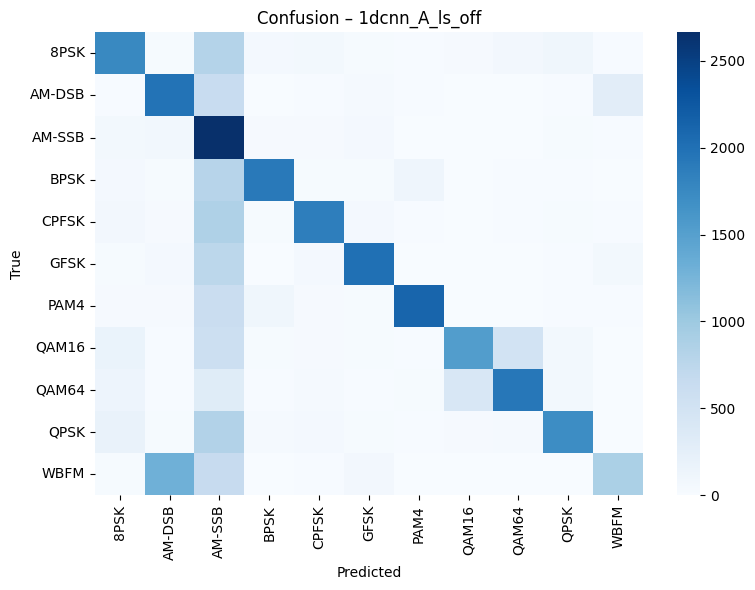

In [ ]:
plot_confusion(labels, preds, class_names=mod_classes, title="Confusion – 1dcnn_A_ls_off")


1dcnn_A_ls_off test accuracy: 0.617030303030303


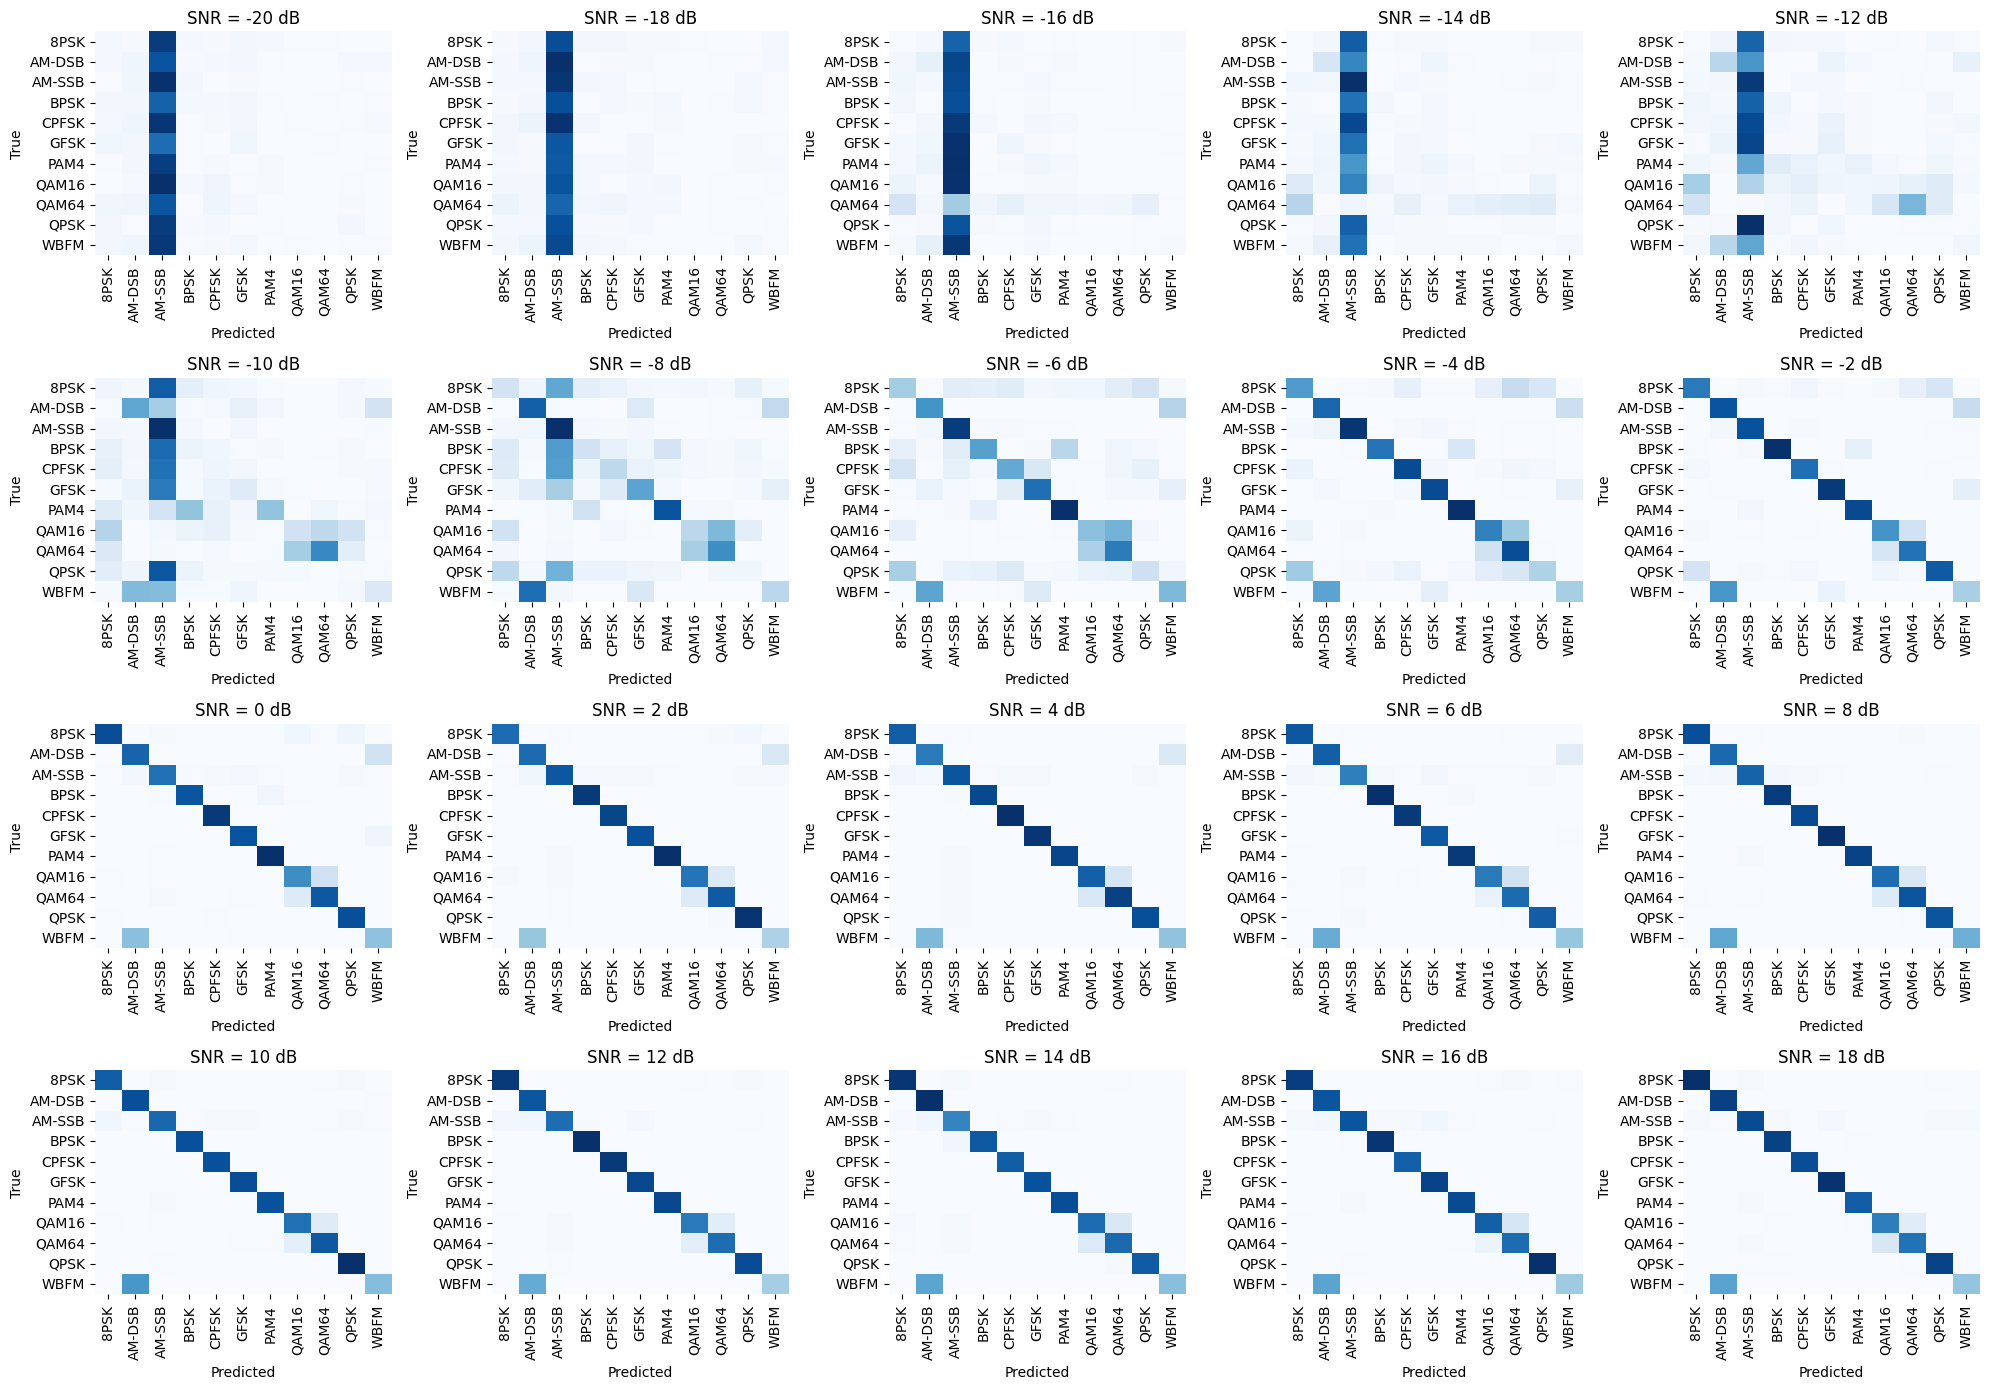

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from eval_utils import evaluate_model

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Build test loader and run inference once
test_loader = make_tensor_loader(X_test, y_test_idx, batch_size=256, shuffle=False)
results = evaluate_model(model_A_ls_off, test_loader, device=device)

preds_all  = results["preds"]   # shape (N,)
labels_all = results["labels"]  # shape (N,)

print("1dcnn_A_ls_off test accuracy:", results["acc"])

# 2. Confusion matrices per SNR
snrs = np.asarray(snr_test)     # make sure this is aligned with X_test order
unique_snrs = np.sort(np.unique(snrs))

n_snr  = len(unique_snrs)
n_cols = 5                      # tweak if you want a different grid layout
n_rows = int(np.ceil(n_snr / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols, 3.5 * n_rows),
                         squeeze=False)

num_classes = len(mod_classes)
labels_order = np.arange(num_classes)

for i, snr in enumerate(unique_snrs):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    idx = np.where(snrs == snr)[0]
    if len(idx) == 0:
        ax.axis("off")
        continue

    cm = confusion_matrix(labels_all[idx], preds_all[idx],
                          labels=labels_order)

    sns.heatmap(
        cm,
        ax=ax,
        cmap="Blues",
        cbar=False,
        xticklabels=mod_classes,
        yticklabels=mod_classes,
    )
    ax.set_title(f"SNR = {snr} dB")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# Hide any unused subplots
for j in range(i + 1, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis("off")

plt.tight_layout()
plt.show()



### References

- T. O’Shea and J. Hoydis, “An Introduction to Deep Learning for the Physical Layer,”  
  *IEEE Transactions on Cognitive Communications and Networking*, 2017.  
  https://arxiv.org/abs/1702.00832

- T. O’Shea, J. Corgan, and T. Clancy, “Convolutional Radio Modulation Recognition Networks,” 2016.  
  https://arxiv.org/abs/1602.04105

- Ziqi Ke and Haris Vikalo, “Real-Time Radio Technology and Modulation Classification via an LSTM Auto-Encoder,”  
  The University of Texas at Austin, 2020.  
  https://arxiv.org/pdf/2011.08295

- Tong He, Zhi Zhang, Hang Zhang, Zhongyue Zhang, Junyuan Xie, and Mu Li,  
  “Bag of Tricks for Image Classification with Convolutional Neural Networks,”  
  *IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) Workshops*, 2019.  
  https://arxiv.org/abs/1812.01187

